# Chapter 6 Notebook: From ARMA to SARIMAX (Unified Forecasting)
1. Import Libraries

## ARIMA: Simple Demand Forecasting

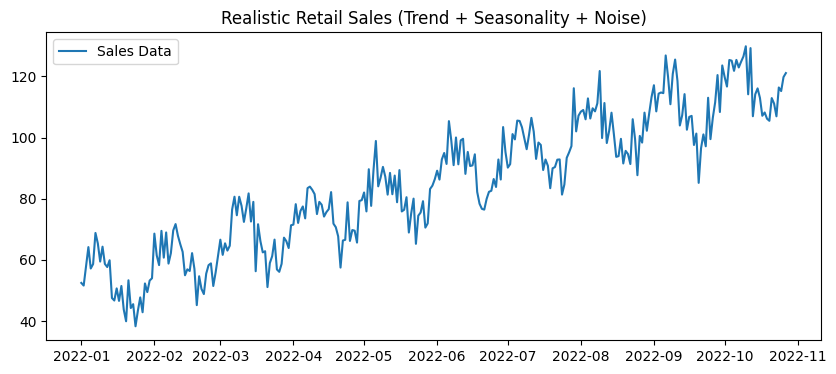

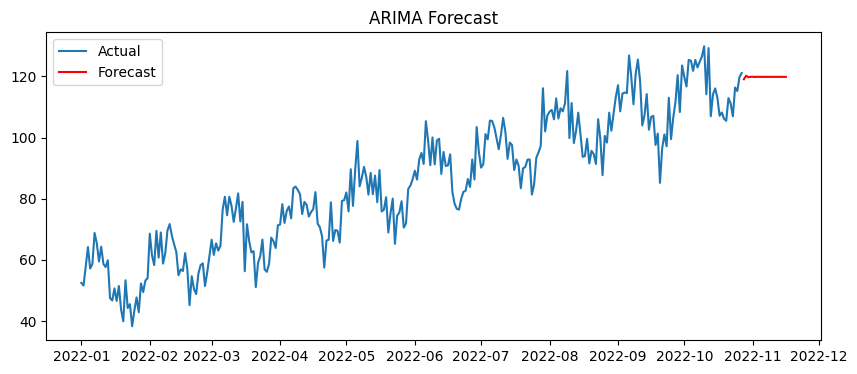

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX

np.random.seed(42)

# Time index
dates = pd.date_range("2022-01-01", periods=300)

# Trend component (slow upward growth)
trend = np.linspace(50, 120, 300)

# Seasonal component (weekly pattern ~30-day cycle)
seasonality = 10 * np.sin(2 * np.pi * np.arange(300) / 30)

# Random noise (real-world randomness)
noise = np.random.normal(0, 5, 300)

# Combine all components
sales = trend + seasonality + noise

# Create DataFrame
df = pd.DataFrame({"sales": sales}, index=dates)

# Plot original series
plt.figure(figsize=(10,4))
plt.plot(df["sales"], label="Sales Data")
plt.title("Realistic Retail Sales (Trend + Seasonality + Noise)")
plt.legend()
plt.show()

# Fit ARIMA model
model = ARIMA(df["sales"], order=(2,1,2))
result = model.fit()

# Forecast
forecast = result.forecast(steps=20)

# Plot forecast
plt.figure(figsize=(10,4))
plt.plot(df["sales"], label="Actual")
plt.plot(forecast, label="Forecast", color="red")
plt.title("ARIMA Forecast")
plt.legend()
plt.show()


## Seasonality in Real Systems

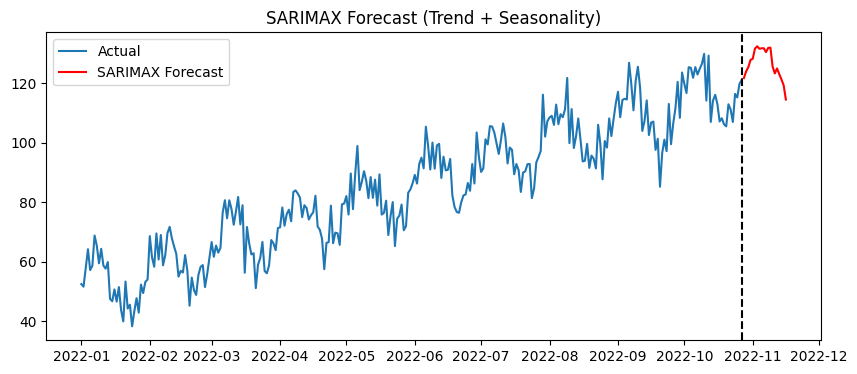

In [4]:

df = pd.DataFrame({"sales": sales}, index=dates)

# ----------------------------
# SARIMAX MODEL
# ----------------------------
model = SARIMAX(
    df["sales"],
    order=(2, 1, 2),
    seasonal_order=(1, 1, 1, 30)  # seasonality = 30 days
)

result = model.fit()

# Forecast
forecast = result.forecast(steps=20)

# Future dates
future_dates = pd.date_range(df.index[-1], periods=21, freq="D")[1:]
forecast_series = pd.Series(forecast, index=future_dates)

# ----------------------------
# PLOT
# ----------------------------
plt.figure(figsize=(10,4))
plt.plot(df["sales"], label="Actual")
plt.plot(forecast_series, label="SARIMAX Forecast", color="red")
plt.axvline(df.index[-1], linestyle="--", color="black")
plt.title("SARIMAX Forecast (Trend + Seasonality)")
plt.legend()
plt.show()


## SARIMAX: Retail Sales with Promotions

In [7]:
df["promotion"] = np.random.choice([0,1], size=len(df))          

exog = df[["promotion"]]

model = SARIMAX(
    df["sales"],
    exog=exog,
    order=(2,1,2),
    seasonal_order=(1,1,1,7)
)
result = model.fit()

future_exog = pd.DataFrame({
    "promotion": np.random.choice([0,1], size=20)
})

forecast = result.forecast(steps=20, exog=future_exog)
forecast


c:\Users\oadsa\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


2022-10-28    193.124404
2022-10-29    201.568691
2022-10-30    209.720967
2022-10-31    211.533826
2022-11-01    207.981302
2022-11-02    198.814707
2022-11-03    194.152130
2022-11-04    196.906186
2022-11-05    204.799389
2022-11-06    213.441511
2022-11-07    214.944848
2022-11-08    211.610624
2022-11-09    202.749760
2022-11-10    197.278036
2022-11-11    200.407750
2022-11-12    208.819559
2022-11-13    217.420318
2022-11-14    218.953087
2022-11-15    215.137714
2022-11-16    205.831622
Freq: D, Name: predicted_mean, dtype: float64

## 1. Real Dataset: Stock Market Data (Apple)

We will use real historical Apple stock data (AAPL) using Yahoo Finance

[*********************100%***********************]  1 of 1 completed


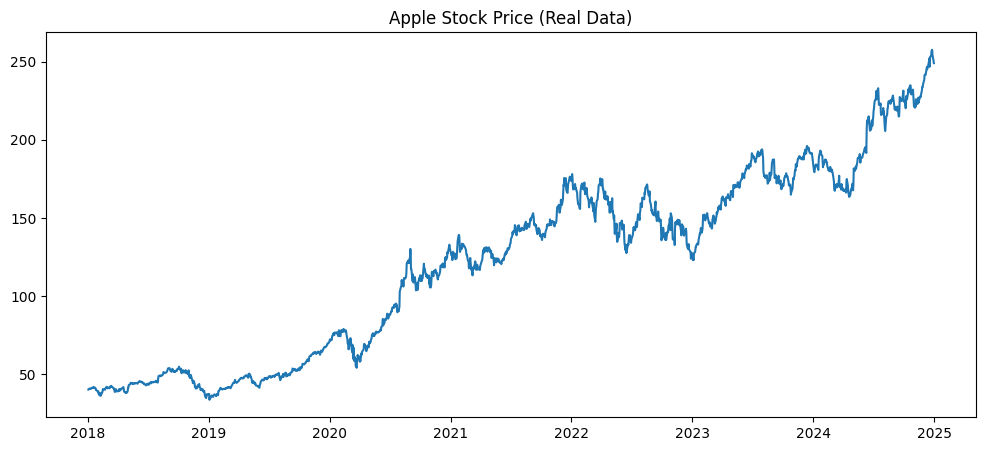

In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf

# ============================================================
# REAL DATA: Apple Stock Price (AAPL)
# ============================================================

df = yf.download("AAPL", start="2018-01-01", end="2025-01-01")

# We use closing price
data = df["Close"]

plt.figure(figsize=(12,5))
plt.plot(data)
plt.title("Apple Stock Price (Real Data)")
plt.show()

## 2. ACF & PACF (Choosing p, q)

<Figure size 1200x400 with 0 Axes>

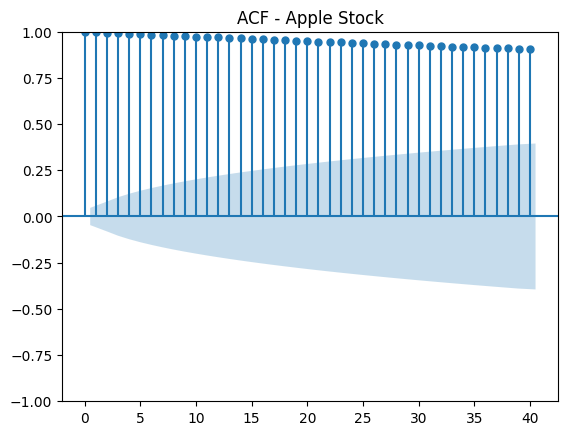

<Figure size 1200x400 with 0 Axes>

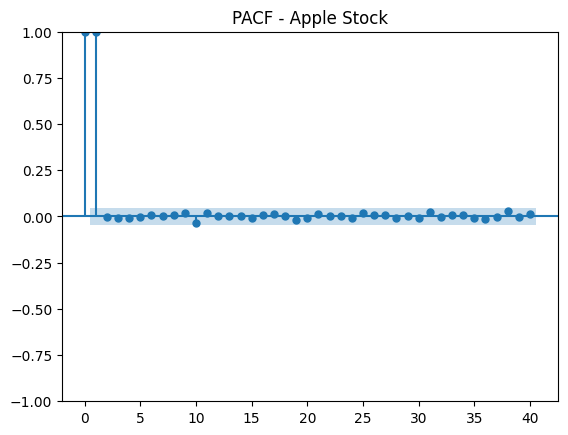

In [9]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# ============================================================
# ACF & PACF ON REAL STOCK DATA
# Helps decide ARIMA parameters
# ============================================================

plt.figure(figsize=(12,4))
plot_acf(data.dropna(), lags=40)
plt.title("ACF - Apple Stock")
plt.show()

plt.figure(figsize=(12,4))
plot_pacf(data.dropna(), lags=40)
plt.title("PACF - Apple Stock")
plt.show()

# USE CASE - APPLE STOCK DATA

## 1. ARIMA on Real Apple Stock Data

c:\Users\oadsa\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\oadsa\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\oadsa\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\oadsa\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is ava

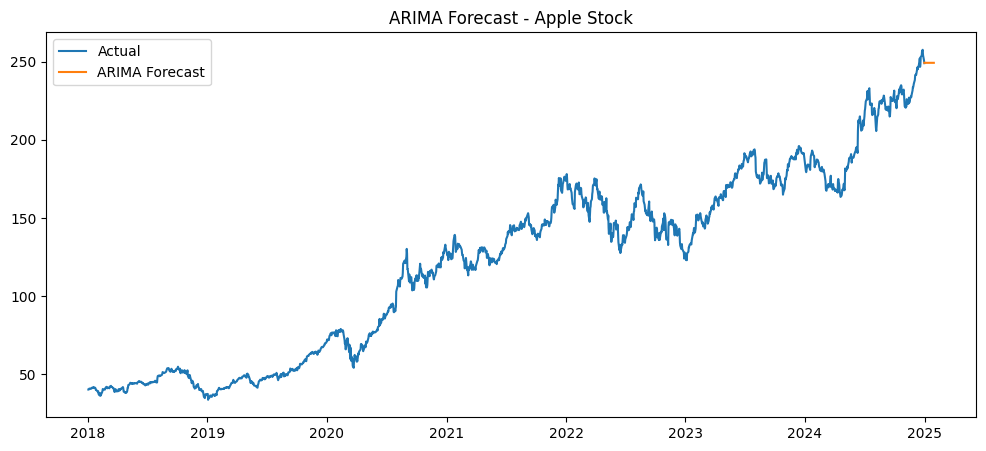

In [10]:
from statsmodels.tsa.arima.model import ARIMA
import matplotlib.pyplot as plt

# ============================================================
# ARIMA MODEL
# Stock data → usually no seasonality, but has trend
# We use (2,1,2) as a strong baseline
# ============================================================

arima_model = ARIMA(data, order=(2,1,2))
arima_result = arima_model.fit()

# Forecast next 30 days
arima_forecast = arima_result.forecast(steps=30)

# Plot
plt.figure(figsize=(12,5))
plt.plot(data, label="Actual")
plt.plot(
    pd.date_range(data.index[-1], periods=30, freq="D"),
    arima_forecast,
    label="ARIMA Forecast"
)

plt.legend()
plt.title("ARIMA Forecast - Apple Stock")
plt.show()

## 2. SARIMA (Seasonality version)

Even though stock is weakly seasonal, we still demonstrate SARIMA learning.

c:\Users\oadsa\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\oadsa\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\oadsa\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
c:\Users\oadsa\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results w

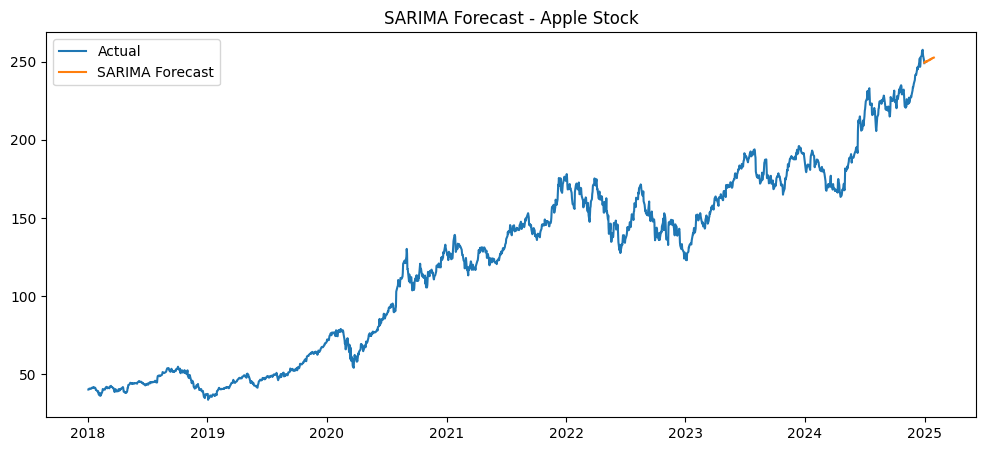

In [11]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

# ============================================================
# SARIMA MODEL
# Adds seasonal structure (e.g., weekly pattern = 7)
# ============================================================

sarima_model = SARIMAX(
    data,
    order=(2,1,2),
    seasonal_order=(1,1,1,7)  # weekly cycle assumption
)

sarima_result = sarima_model.fit()

# Forecast next 30 days
sarima_forecast = sarima_result.forecast(steps=30)

# Plot
plt.figure(figsize=(12,5))
plt.plot(data, label="Actual")
plt.plot(
    pd.date_range(data.index[-1], periods=30, freq="D"),
    sarima_forecast,
    label="SARIMA Forecast"
)

plt.legend()
plt.title("SARIMA Forecast - Apple Stock")
plt.show()

## 3. SARIMAX

In [12]:
# Use real external variable from dataset
exog = df[["Volume"]]

# Normalize (important for stability)
exog = (exog - exog.mean()) / exog.std()

c:\Users\oadsa\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\oadsa\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\oadsa\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
c:\Users\oadsa\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results w

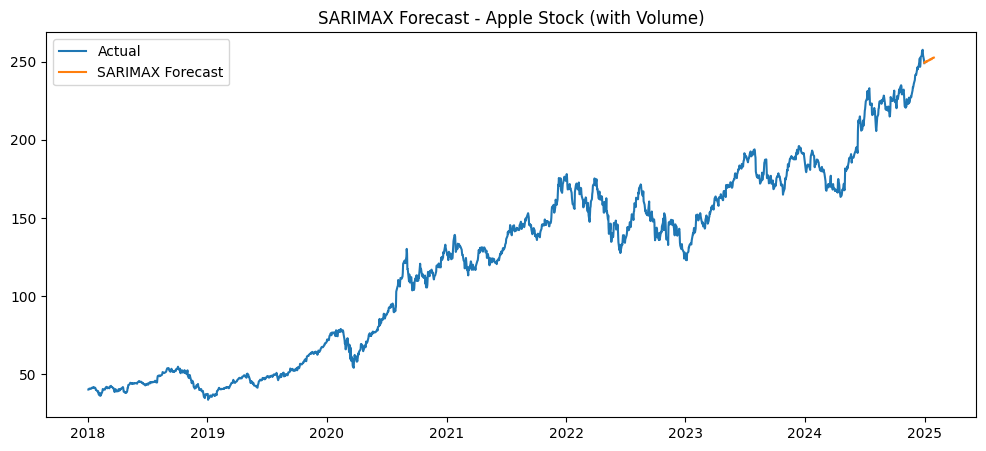

In [13]:
# ============================================================
# SARIMAX MODEL (aka SARIMA + external factor)
# This is closest to real financial forecasting systems
# ============================================================

sarimax_model = SARIMAX(
    data,
    exog=exog,
    order=(2,1,2),
    seasonal_order=(1,1,1,7)
)

sarimax_result = sarimax_model.fit()

# Future exog (we approximate using last values)
future_exog = exog.iloc[-30:].values

sarimax_forecast = sarimax_result.forecast(
    steps=30,
    exog=future_exog
)

# Plot
plt.figure(figsize=(12,5))
plt.plot(data, label="Actual")
plt.plot(
    pd.date_range(data.index[-1], periods=30, freq="D"),
    sarimax_forecast,
    label="SARIMAX Forecast"
)

plt.legend()
plt.title("SARIMAX Forecast - Apple Stock (with Volume)")
plt.show()

## Final Model Comparision

In [14]:
print("""
MODEL COMPARISON (REAL DATA):

ARIMA   → Trend only (basic stock behavior)
SARIMA  → Trend + weak seasonality assumption
SARIMAX → Trend + seasonality + external factors (volume)

FINAL INSIGHT:
SARIMAX is closest to real financial forecasting systems,
but still limited compared to ML/DL models.
""")


MODEL COMPARISON (REAL DATA):

ARIMA   → Trend only (basic stock behavior)
SARIMA  → Trend + weak seasonality assumption
SARIMAX → Trend + seasonality + external factors (volume)

FINAL INSIGHT:
SARIMAX is closest to real financial forecasting systems,
but still limited compared to ML/DL models.

